# Mocap C3D viewer — scrub through time

Plots all markers from `mocap_rgb_calib_sync01.c3d` in 3D.
- The **6 calibration-board markers** (`Board1`…`Board6`) are drawn in distinct colors.
- A **black outline** connects them in order (`Board1`→`Board2`→…→`Board6`→`Board1`).
- The remaining markers (`*6`…`*10`) are noise / background points, drawn in gray.
- Drag the **Frame** slider to scrub, or press **Play** to animate at the recording's frame rate.

> Requires the `telept_server` conda env (has `ezc3d`, `matplotlib`, `ipympl`). Set the notebook kernel to it.


In [1]:
# %% setup
%matplotlib widget
import numpy as np
import ezc3d
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider, Button
from matplotlib.animation import FuncAnimation
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

PATH = "/data/haziq/telept/mocap_rgb_calib_sync01.c3d"

c = ezc3d.c3d(PATH)
pts = c["data"]["points"]            # [4, M, F] X,Y,Z,residual
xyz = pts[:3].astype(float)          # [3, M, F]
res = pts[3].astype(float)           # [M, F]
M, F = xyz.shape[1], xyz.shape[2]
rate = float(c["parameters"]["POINT"]["RATE"]["value"][0])
units = c["parameters"]["POINT"]["UNITS"]["value"][0]

label_keys = sorted(k for k in c["parameters"]["POINT"] if k.startswith("LABELS"))
labels = []
for k in label_keys:
    labels.extend(c["parameters"]["POINT"][k]["value"])
labels = labels[:M]

board_idx = [i for i, l in enumerate(labels) if str(l).startswith("Board")]
noise_idx = [i for i in range(M) if i not in board_idx]
board_order = [labels.index(f"Board{i}") for i in range(1, 7) if f"Board{i}" in labels]
print(f"{PATH}\n  {M} markers, {F} frames @ {rate:.0f} fps ({F/rate:.2f} s), units={units}")
print(f"  board markers : {[labels[i] for i in board_idx]}")
print(f"  other markers : {[labels[i] for i in noise_idx]}")


/data/haziq/telept/mocap_rgb_calib_sync01.c3d
  11 markers, 3237 frames @ 100 fps (32.37 s), units=mm
  board markers : ['Board4', 'Board3', 'Board5', 'Board6', 'Board1', 'Board2']
  other markers : ['*6', '*7', '*8', '*9', '*10']


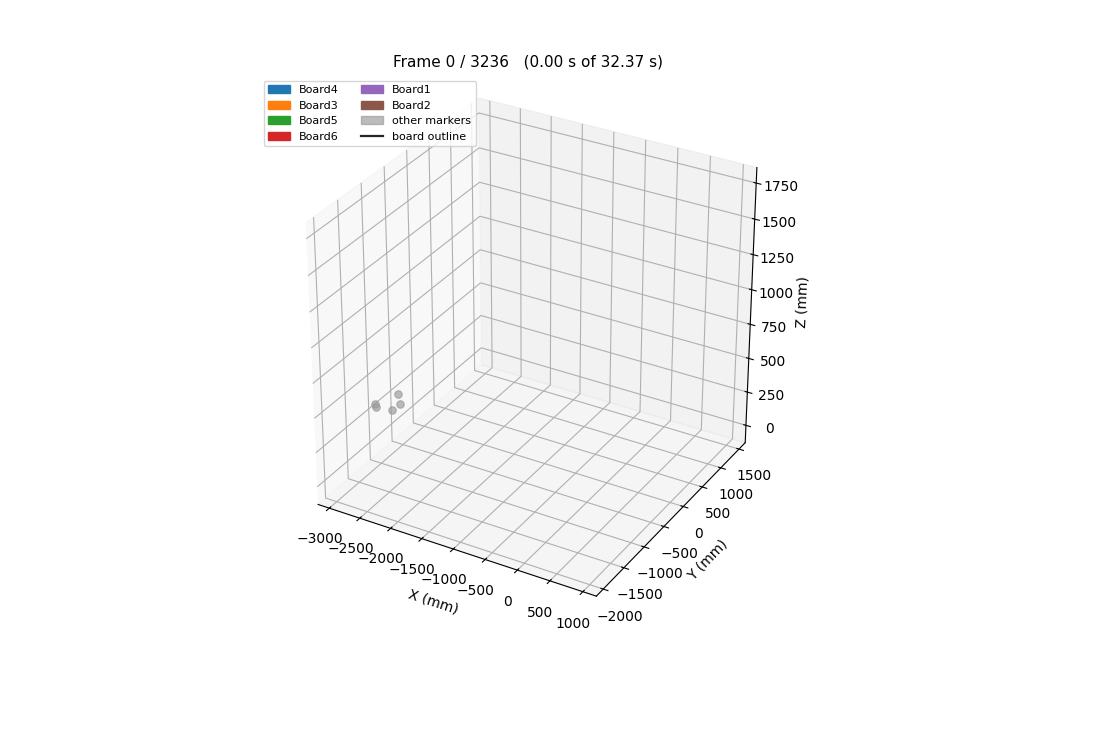

In [2]:
# %% build figure
valid = np.isfinite(xyz).all(axis=0) & (res >= 0)
lo = xyz[:, valid].min(axis=1)
hi = xyz[:, valid].max(axis=1)
pad = (hi - lo) * 0.08 + 1e-3
lims = [(lo[i] - pad[i], hi[i] + pad[i]) for i in range(3)]

cmap = plt.get_cmap("tab10")
board_colors = [cmap(i % 10) for i in range(len(board_idx))]

fig = plt.figure(figsize=(11, 7.5))
ax = fig.add_axes([0.08, 0.18, 0.80, 0.72], projection="3d")

nan_b = [np.nan] * len(board_idx)
nan_n = [np.nan] * len(noise_idx)
scat_board = ax.scatter(nan_b, nan_b, nan_b, s=70, color=board_colors, depthshade=False)
scat_noise = ax.scatter(nan_n, nan_n, nan_n, s=28, color="0.6", alpha=0.65, depthshade=False)

# black outline: Board1 -> Board2 -> ... -> Board6 -> Board1
line_board = ax.plot([], [], [], color="black", lw=1.6, alpha=0.85)[0]

ax.set_xlim(lims[0]); ax.set_ylim(lims[1]); ax.set_zlim(lims[2])
ax.set_xlabel(f"X ({units})"); ax.set_ylabel(f"Y ({units})"); ax.set_zlabel(f"Z ({units})")
ax.set_box_aspect((1, 1, 1))

handles = [Patch(color=board_colors[i], label=str(labels[board_idx[i]])) for i in range(len(board_idx))]
handles.append(Patch(color="0.6", alpha=0.65, label="other markers"))
handles.append(Line2D([0], [0], color="black", lw=1.6, alpha=0.85, label="board outline"))
ax.legend(handles=handles, loc="upper left", fontsize=8, ncol=2)

title = ax.set_title("", fontsize=11)

def update(f):
    f = int(round(f)) % F
    for scat, idx in ((scat_board, board_idx), (scat_noise, noise_idx)):
        x = xyz[:, idx, f].copy()
        ok = np.isfinite(x).all(axis=0) & (res[idx, f] >= 0)
        xx, yy, zz = x[0].copy(), x[1].copy(), x[2].copy()
        xx[~ok] = np.nan; yy[~ok] = np.nan; zz[~ok] = np.nan
        scat.set_offsets(np.column_stack([xx, yy]))
        scat.set_3d_properties(zz, zdir="z")
    # board outline: Board1..Board6 in order, then close back to Board1
    if board_order:
        x = xyz[:, board_order, f].copy()
        ok = np.isfinite(x).all(axis=0) & (res[board_order, f] >= 0)
        xs = list(x[0]) + [x[0, 0]]
        ys = list(x[1]) + [x[1, 0]]
        zs = list(x[2]) + [x[2, 0]]
        okc = list(ok) + [ok[0]]
        xs = [v if o else np.nan for v, o in zip(xs, okc)]
        ys = [v if o else np.nan for v, o in zip(ys, okc)]
        zs = [v if o else np.nan for v, o in zip(zs, okc)]
        line_board.set_data(xs, ys)
        line_board.set_3d_properties(zs)
    title.set_text(f"Frame {f} / {F-1}   ({f/rate:.2f} s of {F/rate:.2f} s)")
    fig.canvas.draw_idle()
    return scat_board, scat_noise, line_board

update(0)
plt.show()


In [3]:
# %% slider + play controls
ax_slider = fig.add_axes([0.13, 0.06, 0.55, 0.035])
slider = Slider(ax_slider, "Frame", 0, F - 1, valinit=0, valstep=1)
slider.on_changed(lambda v: update(v))

ax_play = fig.add_axes([0.72, 0.055, 0.10, 0.05])
play_btn = Button(ax_play, "Play")
ax_reset = fig.add_axes([0.84, 0.055, 0.10, 0.05])
reset_btn = Button(ax_reset, "Reset")

anim = FuncAnimation(fig, lambda _: update(slider.val + 1), None,
                     interval=1000.0 / rate, blit=False, repeat=True,
                     save_count=F, cache_frame_data=False)
anim.event_source.stop()

def toggle_play(_):
    if anim.event_source.running:
        anim.event_source.stop()
        play_btn.label.set_text("Play")
    else:
        anim.event_source.start()
        play_btn.label.set_text("Pause")

def reset(_):
    anim.event_source.stop()
    play_btn.label.set_text("Play")
    slider.set_val(0)

play_btn.on_clicked(toggle_play)
reset_btn.on_clicked(reset)

print("Drag the slider to scrub; hit Play to animate.")

Drag the slider to scrub; hit Play to animate.
